# Clean TADI release data for continuous monitor analysis
Code author: Audrey McManemin

Date started: 2024-10-08
Date last edited: 2024-10-10


## Data description:
Release flow rate data, according to the data given to Stanford by TADI site operators. Timestamps are recorded by the site engineer as he turned the releases on and off. 100% pure CH4 was used so no methane fraction of gas calculations are needed. 

## Script objective:
Load release data for each week and create a dataframe with the following columns
- Datetime: local date and time at the release site  
- True Release Rate (kg/h): release rate at the TADI facility
- tag: Stanford defined tag


In [1]:
# Import necessary packages
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from pathlib import PurePath

# Ignore warnings
warnings.filterwarnings("ignore")

In [3]:
# %% Load and clean the release data

def clean_TADI_release_data_cm(path, sheet_name, cols='B:Z', engine='openpyxl'):
    # read data
    data = pd.read_excel(path, sheet_name=sheet_name, engine=engine, usecols=cols, skiprows=1)        
    # rename columns
    data.columns = ['Week', 'Date', 'BT = BlIND TEST', 'Test N°', 'Test Number', 'ReleaseStart', 'Release Start Stabilized', 'ReleaseEnd', 'Duration (hh:min)', 'Gas', 'Localisation', 'Leak Equipment', 'Leak Type / Location', 'Type of emission', 'Leak localisation - X(m)', 'Leak localisation - Y(m)', 'Leak localisation - Z(m)', 'Flowrate (g/s)', 'Flowrate (kg/h)', 'OP Valve (%)', 'Valve', 'Nominal size of orifice', 'Internal diameter (mm)', 'pressure (bar)', 'Comments']        
    # drop empty rows
    data = data[(data['ReleaseEnd'].notna() & data['Flowrate (kg/h)'].notna())] # & data['Flowrate (kg/h)'] != None]        
    # update format of Week column
    data['Week'] = data['Week'].map({'W25': 1, 'W26': 2, 'W37': 3, 'W38': 4}).fillna(0).astype(int)
    # extract columns for cleaned data
    data = data[['Date', 'ReleaseStart', 'ReleaseEnd', 'Flowrate (kg/h)']]
    # set release ID
    data = data.reset_index(drop=True)
    data['ReleaseID'] = data.index + 1
    df1 = data

    # Initialize an empty list to store the results
    rows = []

    # Loop through each row in df1
    for idx, row in df1.iterrows():

        # Combine 'Date' and 'ReleaseStart'/'ReleaseEnd' to create full datetime objects
        release_start = pd.Timestamp.combine(row['Date'], row['ReleaseStart'])
        release_end = pd.Timestamp.combine(row['Date'], row['ReleaseEnd'])
        
        # Create a minute-by-minute date range between the ReleaseStart and ReleaseEnd
        time_range = pd.date_range(start=release_start, end=release_end, freq='s')
        
        # Create a DataFrame for this time range
        temp_df = pd.DataFrame({
            'Datetime': time_range,  # Every second
            'True Release Rate (kg/h)': row['Flowrate (kg/h)'],  # Assign flowrate to each minute
            'ReleaseID': row['ReleaseID']
        })
        
        # Append this temporary DataFrame to the rows list
        rows.append(temp_df)
        
    # Concatenate all the DataFrames into one
    df2 = pd.concat(rows).reset_index(drop=True)

    full_date_range = pd.date_range(start=df1['Date'].min(), end=df1['Date'].max() + pd.Timedelta(days=1), freq='s')

    # Create a DataFrame with the full minute-by-minute range and initialize True Release Rate as 0
    df2_full = pd.DataFrame({
        'Datetime': full_date_range,
        'True Release Rate (kg/h)': 0,
        'ReleaseID': 0
    })

    df2_full = pd.merge(df2_full, df2, on='Datetime', how='left', suffixes=('_full', ''))

    df2_full['True Release Rate (kg/h)'].fillna(0, inplace=True)
    df2_full = df2_full[['Datetime', 'True Release Rate (kg/h)', 'ReleaseID']]

    df2_full['ReleaseID'] = df2_full['ReleaseID'].fillna(0).astype(int)


    return df2_full

W1_clean_cm.csv
Number of releases:  40


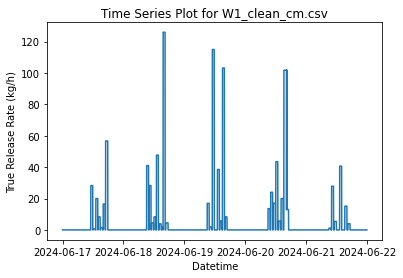

W2_clean_cm.csv
Number of releases:  35


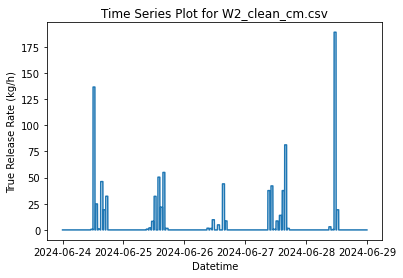

W3_clean_cm.csv
Number of releases:  37


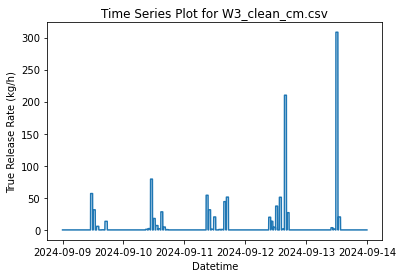

W4_clean_cm.csv
Number of releases:  41


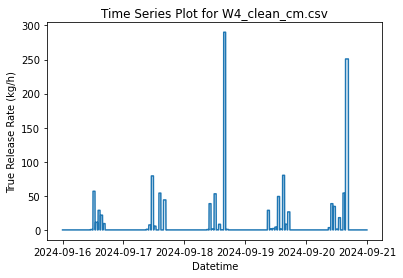

<Figure size 432x288 with 0 Axes>

In [4]:
# read_data
W1_path = PurePath('../release data/Release Data - J1/CONFIDENTIAL_J1_Scenario_IMEO_TADI_2024_June W25 done.xlsx')
W2_path = PurePath('../release data/Release Data - J2/CONFIDENTIAL_J2_Scenario_IMEO_TADI_2024_June W26 done.xlsx')
W3_path = PurePath('../release data/Release Data - S1/CONFIDENTIAL_ Scenario_schedules_IMEO_TADI_2024_September W37 done.xlsx')
W4_path = PurePath('../release data/Release Data - S2/CONFIDENTIAL_Scenario_schedules_IMEO_TADI_2024_September W38 done.xlsx')

# clean data
W1_clean_cm = clean_TADI_release_data_cm(W1_path, sheet_name='June-W25')
W2_clean_cm = clean_TADI_release_data_cm(W2_path, sheet_name='June-W26')
W3_clean_cm = clean_TADI_release_data_cm(W3_path, sheet_name='September-W37')
W4_clean_cm = clean_TADI_release_data_cm(W4_path, sheet_name='September-W38')

# save clean release data
clean_dfs = [
    ("W1_clean_cm.csv", W1_clean_cm),
    ("W2_clean_cm.csv", W2_clean_cm),
    ("W3_clean_cm.csv", W3_clean_cm),
    ("W4_clean_cm.csv", W4_clean_cm)
]
release_data_path = PurePath('02_release_data')

# Loop through each DataFrame and save it to the corresponding CSV file
for filename, df in clean_dfs:
    df.to_csv(release_data_path / filename, index=False)
    print(filename)
    print('Number of releases: ', df['ReleaseID'].max())
    plt.plot(df['Datetime'], df['True Release Rate (kg/h)'])
    plt.xlabel('Datetime')
    plt.ylabel('True Release Rate (kg/h)')
    plt.title(f'Time Series Plot for {filename}')
    plt.show()
    plt.clf()
